

setup

In [ ]:
!pip install yfinance -q

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [ ]:
from enum import auto
ticker = 'SPY'

df = yf.download(
    ticker,
    start = '2010-01-01',
    end = '2026-09-01',
    auto_adjust = True
)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2010-01-04,84.368973,84.413638,83.014067,83.654298,118944600
2010-01-05,84.592323,84.629548,84.011650,84.316879,111579900
2010-01-06,84.651855,84.860302,84.443409,84.510407,116074400
2010-01-07,85.009209,85.113432,84.257309,84.495534,131091100
2010-01-08,85.292130,85.329355,84.614679,84.785900,126402800


In [ ]:
print(df.shape)

(4190, 5)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4190 entries, 2010-01-04 to 2026-08-31
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   4190 non-null   float64
 1   (High, SPY)    4190 non-null   float64
 2   (Low, SPY)     4190 non-null   float64
 3   (Open, SPY)    4190 non-null   float64
 4   (Volume, SPY)  4190 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 196.4 KB
None


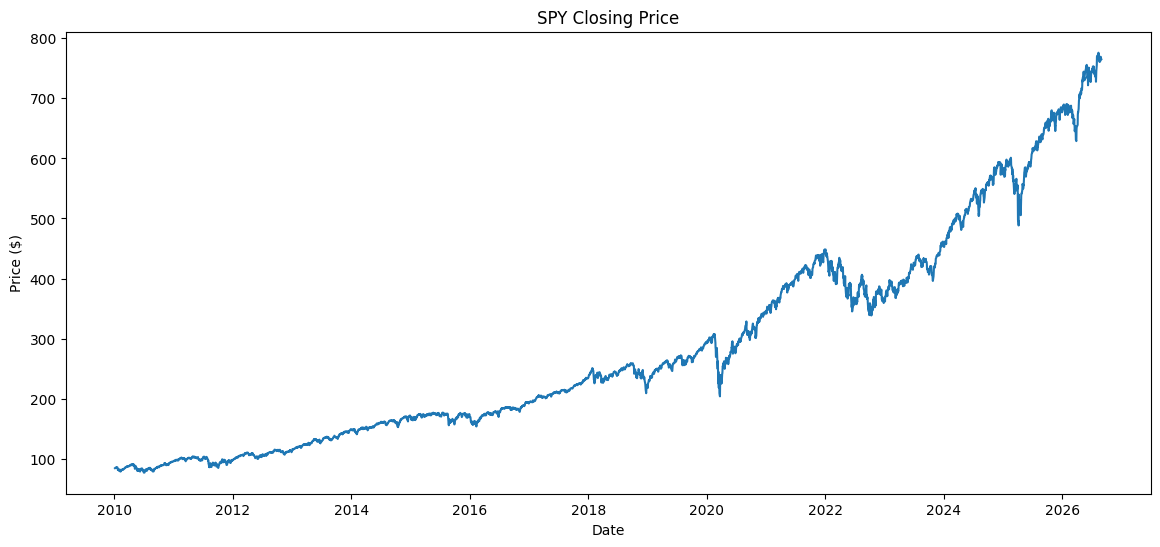

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"])
plt.title("SPY Closing Price")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.show()

In [ ]:
df["Return"] = df["Close"].pct_change()

In [ ]:
df[["Close", "Return"]].head(10)

Price,Close,Return
Ticker,SPY,
Date,,
2010-01-04,84.368973,NaN
2010-01-05,84.592323,0.002647
2010-01-06,84.651855,0.000704
2010-01-07,85.009209,0.004221
2010-01-08,85.292130,0.003328
2010-01-11,85.411224,0.001396
2010-01-12,84.614632,-0.009327
2010-01-13,85.329323,0.008446


In [ ]:
# moving averages
df["SMA_5"] = df["Close"].rolling(5).mean()
df["SMA_20"] = df["Close"].rolling(20).mean()
df["SMA_50"] = df["Close"].rolling(50).mean()

# momentum
df["Momentum_5"] = df["Close"].pct_change(5)
df["Momentum_20"] = df["Close"].pct_change(20)

# volatility
df["Volatility_10"] = df["Return"].rolling(10).std()
df["Volatility_20"] = df["Return"].rolling(20).std()

# volume change
df["Volume_Change"] = df["Volume"].pct_change()

# intraday range
df["High_Low_Range"] = (
    (df["High"] - df["Low"]) / df["Close"]
)

In [ ]:
df.head(10)

Price,Close,High,Low,Open,Volume,Return,SMA_5,SMA_20,SMA_50,Momentum_5,Momentum_20,Volatility_10,Volatility_20,Volume_Change,High_Low_Range
Ticker,SPY,SPY,SPY,SPY,SPY,,,,,,,,,,
Date,,,,,,,,,,,,,,,
2010-01-04,84.368973,84.413638,83.014067,83.654298,118944600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016589
2010-01-05,84.592323,84.629548,84.011650,84.316879,111579900,0.002647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.061917,0.007304
2010-01-06,84.651855,84.860302,84.443409,84.510407,116074400,0.000704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.040281,0.004925
2010-01-07,85.009209,85.113432,84.257309,84.495534,131091100,0.004221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.129371,0.010071
2010-01-08,85.292130,85.329355,84.614679,84.785900,126402800,0.003328,84.782898,NaN,NaN,NaN,NaN,NaN,NaN,-0.035764,0.008379
2010-01-11,85.411224,85.709001,85.046438,85.671782,106375700,0.001396,84.991348,NaN,NaN,0.012353,NaN,NaN,NaN,-0.158439,0.007757
2010-01-12,84.614632,85.024078,84.287070,84.845411,163333500,-0.009327,84.995810,NaN,NaN,0.000264,NaN,NaN,NaN,0.535440,0.008710
2010-01-13,85.329323,85.567548,84.398755,84.830534,161822000,0.008446,85.131303,NaN,NaN,0.008003,NaN,NaN,NaN,-0.009254,0.013697


In [ ]:
df["Target"] = df["Return"].shift(-1)

In [ ]:
df

Price,Close,High,Low,Open,Volume,Return,SMA_5,SMA_20,SMA_50,Momentum_5,Momentum_20,Volatility_10,Volatility_20,Volume_Change,High_Low_Range,Target
Ticker,SPY,SPY,SPY,SPY,SPY,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,
2010-01-04,84.368973,84.413638,83.014067,83.654298,118944600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016589,0.002647
2010-01-05,84.592323,84.629548,84.011650,84.316879,111579900,0.002647,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.061917,0.007304,0.000704
2010-01-06,84.651855,84.860302,84.443409,84.510407,116074400,0.000704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.040281,0.004925,0.004221
2010-01-07,85.009209,85.113432,84.257309,84.495534,131091100,0.004221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.129371,0.010071,0.003328
2010-01-08,85.292130,85.329355,84.614679,84.785900,126402800,0.003328,84.782898,NaN,NaN,NaN,NaN,NaN,NaN,-0.035764,0.008379,0.001396
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-08-25,764.012756,764.880657,761.159855,764.262137,27422300,0.003196,763.456152,762.904056,750.767266,-0.002007,0.033812,0.005098,0.008372,-0.154439,0.004870,0.000222
2026-08-26,764.182373,765.449186,762.037674,762.835681,28751600,0.000222,762.861633,764.730518,751.030404,-0.003875,0.050201,0.004994,0.007362,0.048475,0.004464,0.006553


In [ ]:
df = df.dropna()

In [ ]:
print(df.shape)

(4140, 16)


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume,Return,SMA_5,SMA_20,SMA_50,Momentum_5,Momentum_20,Volatility_10,Volatility_20,Volume_Change,High_Low_Range,Target
Ticker,SPY,SPY,SPY,SPY,SPY,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,
2010-03-16,86.661888,86.743773,85.976986,86.215211,168673000,0.007966,86.026120,83.948355,83.072731,0.017036,0.060780,0.004485,0.005395,0.148867,0.008848,0.005927
2010-03-17,87.175560,87.458456,86.669331,86.922448,177468100,0.005927,86.343256,84.202958,83.128863,0.018526,0.062035,0.004417,0.005422,0.052143,0.009052,-0.000513
2010-03-18,87.130882,87.302103,86.780988,87.182994,196509100,-0.000513,86.579994,84.431132,83.179634,0.013772,0.055270,0.004657,0.005433,0.107293,0.005981,-0.005061
2010-03-19,86.689896,87.676622,86.353508,86.689896,226641100,-0.005061,86.727042,84.628695,83.220395,0.008554,0.047756,0.003771,0.005704,0.153336,0.015263,0.005346
2010-03-22,87.153343,87.310327,86.144192,86.196519,184477800,0.005346,86.962314,84.848687,83.263278,0.013682,0.053168,0.003860,0.005718,-0.186036,0.013380,0.007033


In [ ]:
features = [
    "Return",
    "SMA_5",
    "SMA_20",
    "SMA_50",
    "Momentum_5",
    "Momentum_20",
    "Volatility_10",
    "Volatility_20",
    "Volume_Change",
    "High_Low_Range"
]

X = df[features]
y = df["Target"]

In [ ]:
print(X.shape)
print(y.shape)

(4140, 10)
(4140,)


train/validation/test split

In [ ]:
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print("Train:", train_df.index.min(), "→", train_df.index.max())
print("Validation:", val_df.index.min(), "→", val_df.index.max())
print("Test:", test_df.index.min(), "→", test_df.index.max())

Train: 2010-03-16 00:00:00 → 2021-09-16 00:00:00
Validation: 2021-09-17 00:00:00 → 2024-03-07 00:00:00
Test: 2024-03-08 00:00:00 → 2026-08-28 00:00:00


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
X_train = train_df[features].values
y_train = train_df["Target"].values

X_val = val_df[features].values
y_val = val_df["Target"].values

X_test = test_df[features].values
y_test = test_df["Target"].values

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

60-day sequences for LSTM

In [ ]:
def create_sequences(X, y, sequence_length=60):
    X_sequences = []
    y_sequences = []

    for i in range(sequence_length - 1, len(X)):
        X_sequences.append(
            X[i - sequence_length + 1:i + 1]
        )

        y_sequences.append(y[i])

    return np.array(X_sequences), np.array(y_sequences)

In [ ]:
seq_length = 60

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train,
    seq_length
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled,
    y_val,
    seq_length
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test,
    seq_length
)

In [ ]:
print("Training:", X_train_seq.shape)
print("Validation:", X_val_seq.shape)
print("Testing:", X_test_seq.shape)

Training: (2839, 60, 10)
Validation: (562, 60, 10)
Testing: (562, 60, 10)


pytorch

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

Using: cpu


In [ ]:
X_train_tensor = torch.tensor(
    X_train_seq,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_seq,
    dtype=torch.float32
).unsqueeze(1)

X_val_tensor = torch.tensor(
    X_val_seq,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val_seq,
    dtype=torch.float32
).unsqueeze(1)

X_test_tensor = torch.tensor(
    X_test_seq,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test_seq,
    dtype=torch.float32
).unsqueeze(1)

In [ ]:
print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([2839, 60, 10])
torch.Size([2839, 1])


In [ ]:
BATCH_SIZE = 64

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

LSTM - Long Short Term Memory

In [ ]:
class LSTMModel(nn.Module):

  def __init__(
      self,
      input_size,
      hidden_size=64,
      num_layers=2,
      dropout=0.2
  ):
    super().__init__()

    self.lstm = nn.LSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        batch_first=True,
        dropout=dropout
    )

    self.fc1 = nn.Linear(hidden_size, 32)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(32, 1)

  def forward(self, x):

    lstm_out, _ = self.lstm(x)

    # output from final timestep
    last_output = lstm_out[:, -1, :]

    x = self.fc1(last_output)
    x = self.relu(x)
    x = self.fc2(x)

    return x

In [ ]:
input_size = len(features)

model = LSTMModel(
    input_size=input_size,
    hidden_size=64,
    num_layers=2,
    dropout=0.2
).to(device)

print(model)

LSTMModel(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


loss function & optimizer

In [ ]:
criterion = nn.MSELoss()

In [ ]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
criterion

MSELoss()

training lstm

In [ ]:
EPOCHS = 30

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # training

    model.train()

    total_train_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # validation

    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val Loss: {avg_val_loss:.6f}"
    )

Epoch 1/30 | Train Loss: 0.000517 | Val Loss: 0.000191
Epoch 2/30 | Train Loss: 0.000204 | Val Loss: 0.000143
Epoch 3/30 | Train Loss: 0.000180 | Val Loss: 0.000166
Epoch 4/30 | Train Loss: 0.000156 | Val Loss: 0.000146
Epoch 5/30 | Train Loss: 0.000118 | Val Loss: 0.000144
Epoch 6/30 | Train Loss: 0.000113 | Val Loss: 0.000139
Epoch 7/30 | Train Loss: 0.000112 | Val Loss: 0.000140
Epoch 8/30 | Train Loss: 0.000111 | Val Loss: 0.000140
Epoch 9/30 | Train Loss: 0.000110 | Val Loss: 0.000141
Epoch 10/30 | Train Loss: 0.000110 | Val Loss: 0.000144
Epoch 11/30 | Train Loss: 0.000109 | Val Loss: 0.000146
Epoch 12/30 | Train Loss: 0.000110 | Val Loss: 0.000148
Epoch 13/30 | Train Loss: 0.000109 | Val Loss: 0.000142
Epoch 14/30 | Train Loss: 0.000110 | Val Loss: 0.000160
Epoch 15/30 | Train Loss: 0.000113 | Val Loss: 0.000153
Epoch 16/30 | Train Loss: 0.000113 | Val Loss: 0.000150
Epoch 17/30 | Train Loss: 0.000113 | Val Loss: 0.000146
Epoch 18/30 | Train Loss: 0.000108 | Val Loss: 0.000153
E

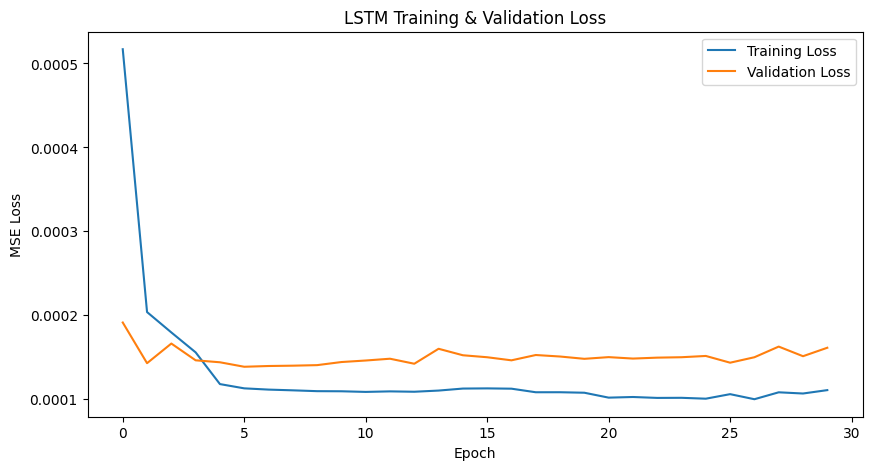

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training & Validation Loss")

plt.legend()
plt.show()

Predictions on test set

In [ ]:
model.eval()

X_test_device = X_test_tensor.to(device)

with torch.no_grad():
    test_predictions = model(X_test_device)

test_predictions = (
    test_predictions
    .cpu()
    .numpy()
    .flatten()
)

actual_returns = y_test_seq

print("Predictions:", test_predictions[:10])
print("Actual:", actual_returns[:10])

Predictions: [0.00067781 0.00068433 0.00029096 0.00070478 0.00096457 0.00055764
 0.00061198 0.00119448 0.00062791 0.00084201]
Actual: [ 1.11792755e-03  1.18853195e-02 -1.89215804e-05 -1.21547011e-03
  3.08967676e-03  2.40821898e-03  8.21302442e-03  2.01363463e-03
  6.08158710e-04  7.95891114e-03]


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(
    mean_squared_error(actual_returns, test_predictions)
)

mae = mean_absolute_error(
    actual_returns,
    test_predictions
)

directional_accuracy = np.mean(
    np.sign(test_predictions) == np.sign(actual_returns)
)

print(f"RMSE: {rmse:.6f}")
print(f"MAE: {mae:.6f}")
print(f"Directional Accuracy: {directional_accuracy:.2%}")

RMSE: 0.012486
MAE: 0.009014
Directional Accuracy: 48.22%


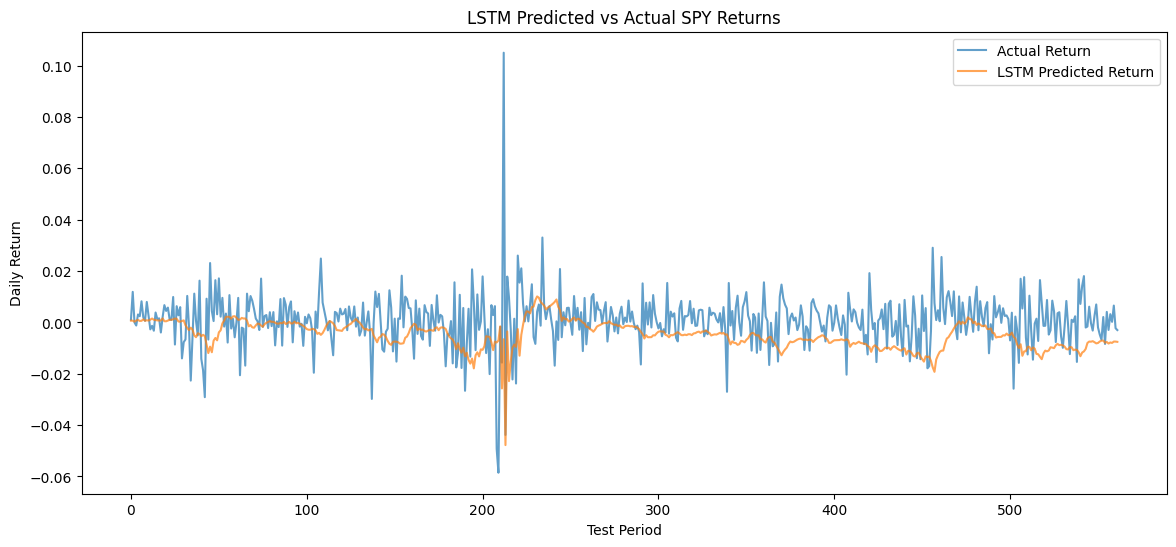

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual_returns,
    label="Actual Return",
    alpha=0.7
)

plt.plot(
    test_predictions,
    label="LSTM Predicted Return",
    alpha=0.7
)

plt.title("LSTM Predicted vs Actual SPY Returns")
plt.xlabel("Test Period")
plt.ylabel("Daily Return")

plt.legend()
plt.show()

In [ ]:
test_dates = test_df.index[seq_length - 1:]

results = pd.DataFrame({
    "Actual_Return": actual_returns,
    "Predicted_Return": test_predictions
}, index=test_dates)

results.head(10)

,Actual_Return,Predicted_Return
Date,,
2024-06-03,0.001118,0.000678
2024-06-04,0.011885,0.000684
2024-06-05,-0.000019,0.000291
2024-06-06,-0.001215,0.000705
2024-06-07,0.003090,0.000965
2024-06-10,0.002408,0.000558
2024-06-11,0.008213,0.000612
2024-06-12,0.002014,0.001194
2024-06-13,0.000608,0.000628


In [ ]:
print(results.shape)
print(results.index.min())
print(results.index.max())

(562, 2)
2024-06-03 00:00:00
2026-08-28 00:00:00


In [ ]:
print(len(results) == len(test_predictions))

True


Trading Signals

In [ ]:
THRESHOLD = 0.001

In [ ]:
results["Signal"] = 0

results.loc[
    results["Predicted_Return"] > THRESHOLD,
    "Signal"
] = 1

results.loc[
    results["Predicted_Return"] < -THRESHOLD,
    "Signal"
] = -1

In [ ]:
print(results["Signal"].value_counts())

Signal
-1    419
 0     90
 1     53
Name: count, dtype: int64


In [ ]:
results["Strategy_Return"] = (
    results["Signal"] *
    results["Actual_Return"]
)

In [ ]:
TRANSACTION_COST = 0.0005

In [ ]:
results["Trade"] = (
    results["Signal"]
    .diff()
    .abs()
    .fillna(results["Signal"].abs())
)

In [ ]:
results["Strategy_Return_Net"] = (
    results["Strategy_Return"]
    - results["Trade"] * TRANSACTION_COST
)

equity curves

In [ ]:
INITIAL_CAPITAL = 10000

results["LSTM_Portfolio"] = (
    INITIAL_CAPITAL *
    (1 + results["Strategy_Return_Net"]).cumprod()
)

results["Buy_Hold_Portfolio"] = (
    INITIAL_CAPITAL *
    (1 + results["Actual_Return"]).cumprod()
)

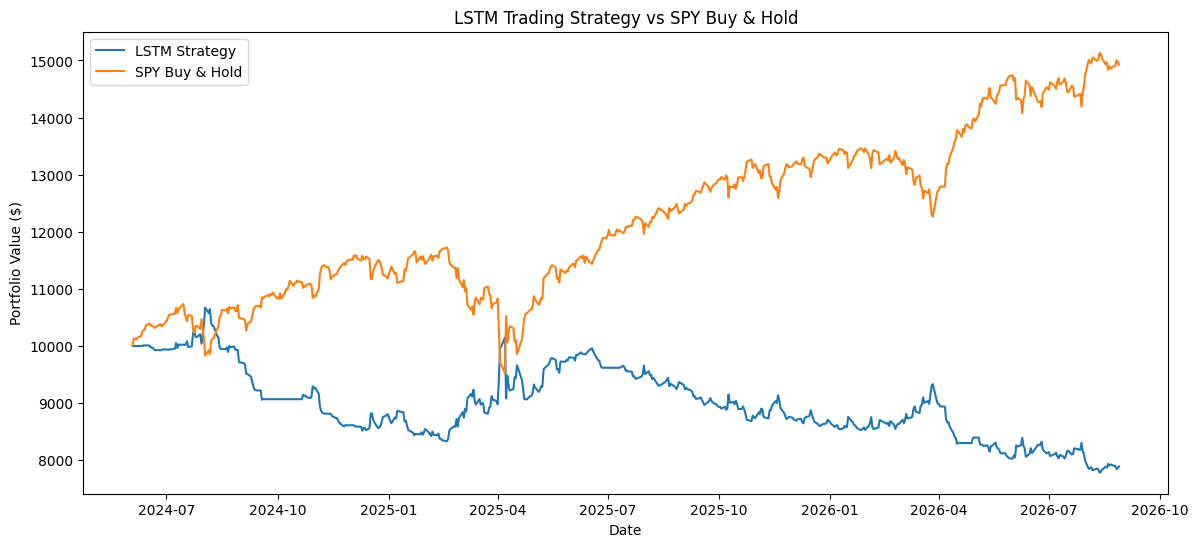

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    results.index,
    results["LSTM_Portfolio"],
    label="LSTM Strategy"
)

plt.plot(
    results.index,
    results["Buy_Hold_Portfolio"],
    label="SPY Buy & Hold"
)

plt.title("LSTM Trading Strategy vs SPY Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")

plt.legend()
plt.show()

In [ ]:
# Total returns
lstm_total_return = (
    results["LSTM_Portfolio"].iloc[-1] /
    INITIAL_CAPITAL - 1
)

buy_hold_total_return = (
    results["Buy_Hold_Portfolio"].iloc[-1] /
    INITIAL_CAPITAL - 1
)

# Annualized Sharpe ratio
lstm_sharpe = (
    results["Strategy_Return_Net"].mean() /
    results["Strategy_Return_Net"].std()
) * np.sqrt(252)

buy_hold_sharpe = (
    results["Actual_Return"].mean() /
    results["Actual_Return"].std()
) * np.sqrt(252)


# Maximum drawdown function
def max_drawdown(returns):

    cumulative = (1 + returns).cumprod()

    running_max = cumulative.cummax()

    drawdown = (
        cumulative - running_max
    ) / running_max

    return drawdown.min()


lstm_drawdown = max_drawdown(
    results["Strategy_Return_Net"]
)

buy_hold_drawdown = max_drawdown(
    results["Actual_Return"]
)


# Number of position changes
num_trades = (results["Trade"] > 0).sum()


print("----- LSTM STRATEGY -----")
print(f"Total Return: {lstm_total_return:.2%}")
print(f"Sharpe Ratio: {lstm_sharpe:.2f}")
print(f"Max Drawdown: {lstm_drawdown:.2%}")
print(f"Trades: {num_trades}")

print()

print("----- BUY & HOLD -----")
print(f"Total Return: {buy_hold_total_return:.2%}")
print(f"Sharpe Ratio: {buy_hold_sharpe:.2f}")
print(f"Max Drawdown: {buy_hold_drawdown:.2%}")

----- LSTM STRATEGY -----
Total Return: -21.10%
Sharpe Ratio: -0.58
Max Drawdown: -27.10%
Trades: 45

----- BUY & HOLD -----
Total Return: 49.25%
Sharpe Ratio: 1.18
Max Drawdown: -18.76%


resetting model

In [ ]:
model = LSTMModel(
    input_size=len(features),
    hidden_size=64,
    num_layers=2,
    dropout=0.2
).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
EPOCHS = 50

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_model_state = None
patience = 5
patience_counter = 0

for epoch in range(EPOCHS):

    # training
    model.train()
    total_train_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

    # validation
    model.eval()
    total_val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val Loss: {avg_val_loss:.6f}"
    )

    # early stopping

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        best_model_state = {
            key: value.cpu().clone()
            for key, value in model.state_dict().items()
        }

        patience_counter = 0

    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("Early stopping!")
        break

Epoch 1/50 | Train Loss: 0.000172 | Val Loss: 0.000185
Epoch 2/50 | Train Loss: 0.000160 | Val Loss: 0.000142
Epoch 3/50 | Train Loss: 0.000116 | Val Loss: 0.000145
Epoch 4/50 | Train Loss: 0.000113 | Val Loss: 0.000144
Epoch 5/50 | Train Loss: 0.000112 | Val Loss: 0.000176
Epoch 6/50 | Train Loss: 0.000115 | Val Loss: 0.000162
Epoch 7/50 | Train Loss: 0.000118 | Val Loss: 0.000152
Early stopping!


In [ ]:
model.load_state_dict(best_model_state)
model = model.to(device)

print(f"Best Validation Loss: {best_val_loss:.6f}")

Best Validation Loss: 0.000142


In [ ]:
torch.save(
    model.state_dict(),
    "lstm_spy_model.pth"
)

In [ ]:
model.eval()

with torch.no_grad():
    new_predictions = model(
        X_test_tensor.to(device)
    ).cpu().numpy().flatten()

actual_returns = y_test_seq

In [ ]:
new_directional_accuracy = np.mean(
    np.sign(new_predictions) == np.sign(actual_returns)
)

print(
    f"Directional Accuracy: "
    f"{new_directional_accuracy:.2%}"
)

Directional Accuracy: 56.94%


new backtest

In [127]:
test_dates = test_df.index[seq_length - 1:]

new_results = pd.DataFrame({
    "Actual_Return": actual_returns,
    "Predicted_Return": new_predictions
}, index=test_dates)

THRESHOLD = 0.001
TRANSACTION_COST = 0.0005
INITIAL_CAPITAL = 10000

In [128]:
new_results["Signal"] = 0

new_results.loc[
    new_results["Predicted_Return"] > THRESHOLD,
    "Signal"
] = 1

new_results.loc[
    new_results["Predicted_Return"] < -THRESHOLD,
    "Signal"
] = -1

In [129]:
new_results["Strategy_Return"] = (
    new_results["Signal"] *
    new_results["Actual_Return"]
)

In [130]:
new_results["Trade"] = (
    new_results["Signal"]
    .diff()
    .abs()
    .fillna(new_results["Signal"].abs())
)

new_results["Strategy_Return_Net"] = (
    new_results["Strategy_Return"]
    - new_results["Trade"] * TRANSACTION_COST
)

In [131]:
new_results["LSTM_Portfolio"] = (
    INITIAL_CAPITAL *
    (1 + new_results["Strategy_Return_Net"]).cumprod()
)

new_results["Buy_Hold_Portfolio"] = (
    INITIAL_CAPITAL *
    (1 + new_results["Actual_Return"]).cumprod()
)

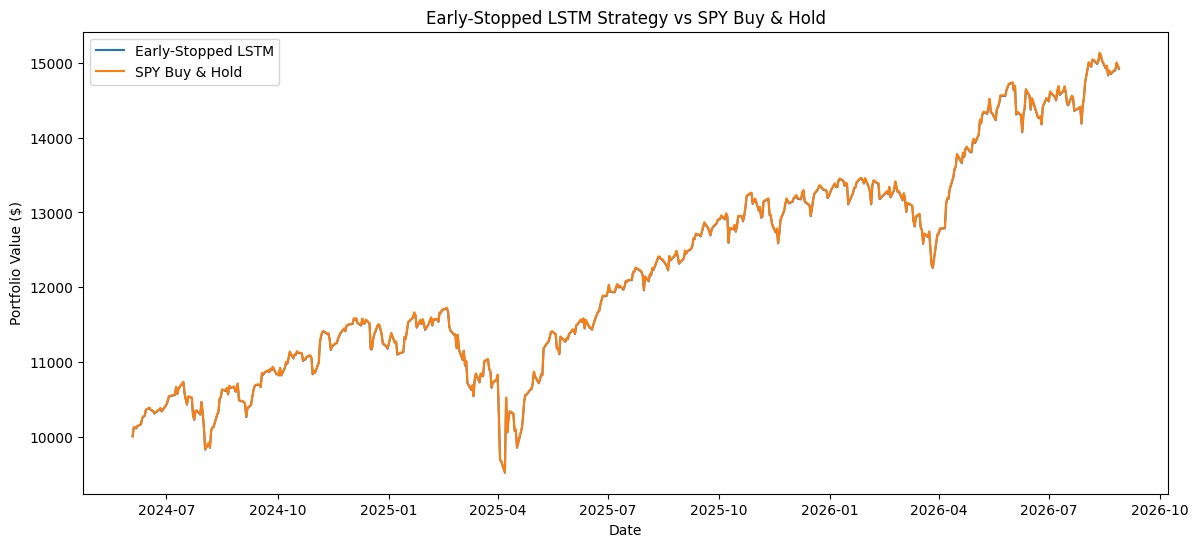

In [132]:
plt.figure(figsize=(14, 6))

plt.plot(
    new_results.index,
    new_results["LSTM_Portfolio"],
    label="Early-Stopped LSTM"
)

plt.plot(
    new_results.index,
    new_results["Buy_Hold_Portfolio"],
    label="SPY Buy & Hold"
)

plt.title("Early-Stopped LSTM Strategy vs SPY Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")

plt.legend()
plt.show()

In [133]:
print(
    "LSTM Final Value:",
    f"${new_results['LSTM_Portfolio'].iloc[-1]:,.2f}"
)

print(
    "Buy & Hold Final Value:",
    f"${new_results['Buy_Hold_Portfolio'].iloc[-1]:,.2f}"
)

print(
    "Directional Accuracy:",
    f"{new_directional_accuracy:.2%}"
)

LSTM Final Value: $14,917.55
Buy & Hold Final Value: $14,925.01
Directional Accuracy: 56.94%


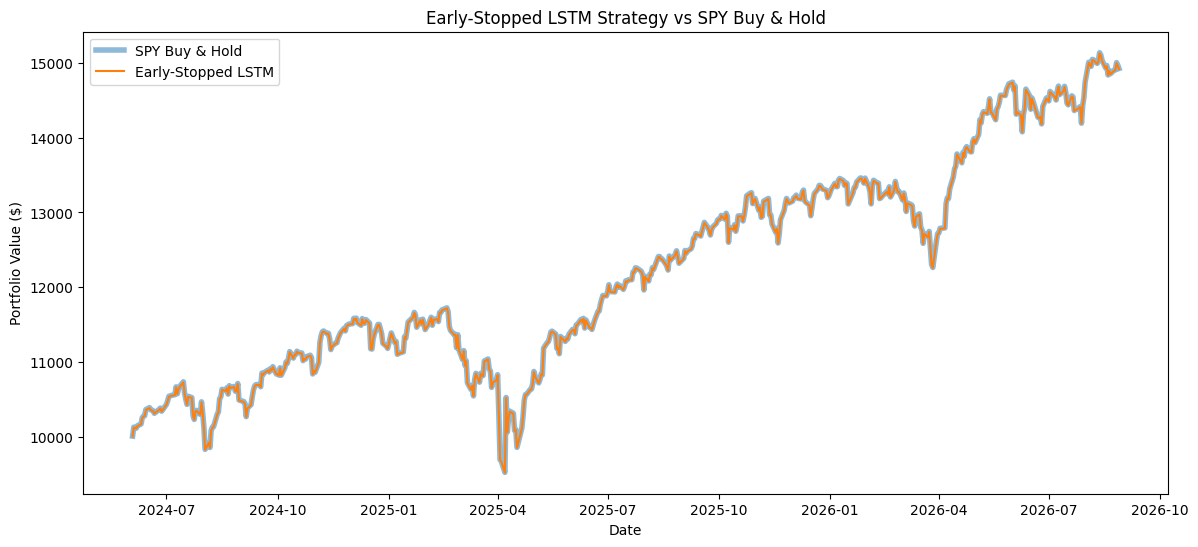

In [134]:
plt.figure(figsize=(14, 6))

plt.plot(
    new_results.index,
    new_results["Buy_Hold_Portfolio"],
    label="SPY Buy & Hold",
    linewidth=4,
    alpha=0.5
)

plt.plot(
    new_results.index,
    new_results["LSTM_Portfolio"],
    label="Early-Stopped LSTM",
    linewidth=1.5
)

plt.title("Early-Stopped LSTM Strategy vs SPY Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")

plt.legend()
plt.show()

In [135]:
always_up_accuracy = np.mean(actual_returns > 0)

print(
    f"Always-Up Baseline Accuracy: "
    f"{always_up_accuracy:.2%}"
)

Always-Up Baseline Accuracy: 56.94%


In [136]:
print(new_results["Signal"].value_counts())

print("\nPercent of days:")
print(
    new_results["Signal"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

Signal
1    562
Name: count, dtype: int64

Percent of days:
Signal
1    100.0
Name: proportion, dtype: float64


classification target

In [137]:
df["Direction_Target"] = (df["Target"] > 0).astype(int)

/tmp/ipykernel_6182/2903213401.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Direction_Target"] = (df["Target"] > 0).astype(int)


In [139]:
y_train_direction = (train_df["Target"].values > 0).astype(int)
y_val_direction = (val_df["Target"].values > 0).astype(int)
y_test_direction = (test_df["Target"].values > 0).astype(int)

In [140]:
X_train_seq_cls, y_train_seq_cls = create_sequences(
    X_train_scaled,
    y_train_direction,
    seq_length
)

X_val_seq_cls, y_val_seq_cls = create_sequences(
    X_val_scaled,
    y_val_direction,
    seq_length
)

X_test_seq_cls, y_test_seq_cls = create_sequences(
    X_test_scaled,
    y_test_direction,
    seq_length
)

In [141]:
print(np.unique(y_train_seq_cls, return_counts=True))

(array([0, 1]), array([1258, 1581]))


convert classification sequences to PyTorch tensors

In [142]:
X_train_cls_tensor = torch.tensor(
    X_train_seq_cls,
    dtype=torch.float32
)

y_train_cls_tensor = torch.tensor(
    y_train_seq_cls,
    dtype=torch.float32
).unsqueeze(1)

X_val_cls_tensor = torch.tensor(
    X_val_seq_cls,
    dtype=torch.float32
)

y_val_cls_tensor = torch.tensor(
    y_val_seq_cls,
    dtype=torch.float32
).unsqueeze(1)

X_test_cls_tensor = torch.tensor(
    X_test_seq_cls,
    dtype=torch.float32
)

y_test_cls_tensor = torch.tensor(
    y_test_seq_cls,
    dtype=torch.float32
).unsqueeze(1)

In [143]:
print(X_train_cls_tensor.shape)
print(y_train_cls_tensor.shape)

torch.Size([2839, 60, 10])
torch.Size([2839, 1])


In [144]:
BATCH_SIZE = 64

train_cls_dataset = TensorDataset(
    X_train_cls_tensor,
    y_train_cls_tensor
)

val_cls_dataset = TensorDataset(
    X_val_cls_tensor,
    y_val_cls_tensor
)

train_cls_loader = DataLoader(
    train_cls_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_cls_loader = DataLoader(
    val_cls_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

classification lstm

In [149]:
class LSTMClassifier(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        dropout=0.2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc1 = nn.Linear(hidden_size, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):

        lstm_out, _ = self.lstm(x)

        last_output = lstm_out[:, -1, :]

        x = self.fc1(last_output)
        x = self.relu(x)
        x = self.fc2(x)

        return x

In [150]:
classifier = LSTMClassifier(
    input_size=len(features),
    hidden_size=64,
    num_layers=2,
    dropout=0.2
).to(device)

In [151]:
cls_criterion = nn.BCEWithLogitsLoss()

In [152]:
cls_optimizer = torch.optim.Adam(
    classifier.parameters(),
    lr=0.001
)

training with early stopping

In [153]:
EPOCHS = 50
PATIENCE = 5

train_cls_losses = []
val_cls_losses = []

best_cls_val_loss = float("inf")
best_cls_model_state = None

patience_counter = 0

for epoch in range(EPOCHS):

    # training

    classifier.train()

    total_train_loss = 0

    for X_batch, y_batch in train_cls_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        cls_optimizer.zero_grad()

        logits = classifier(X_batch)

        loss = cls_criterion(
            logits,
            y_batch
        )

        loss.backward()

        cls_optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = (
        total_train_loss /
        len(train_cls_loader)
    )

    # validation

    classifier.eval()

    total_val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_cls_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = classifier(X_batch)

            loss = cls_criterion(
                logits,
                y_batch
            )

            total_val_loss += loss.item()

    avg_val_loss = (
        total_val_loss /
        len(val_cls_loader)
    )

    train_cls_losses.append(avg_train_loss)
    val_cls_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val Loss: {avg_val_loss:.6f}"
    )

    # early stopping

    if avg_val_loss < best_cls_val_loss:

        best_cls_val_loss = avg_val_loss

        best_cls_model_state = {
            key: value.cpu().clone()
            for key, value
            in classifier.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1

    if patience_counter >= PATIENCE:

        print("Early stopping!")
        break

Epoch 1/50 | Train Loss: 0.692619 | Val Loss: 0.705827
Epoch 2/50 | Train Loss: 0.689666 | Val Loss: 0.697302
Epoch 3/50 | Train Loss: 0.687166 | Val Loss: 0.700371
Epoch 4/50 | Train Loss: 0.686906 | Val Loss: 0.701655
Epoch 5/50 | Train Loss: 0.686847 | Val Loss: 0.702053
Epoch 6/50 | Train Loss: 0.686701 | Val Loss: 0.702494
Epoch 7/50 | Train Loss: 0.686492 | Val Loss: 0.702545
Early stopping!


In [154]:
classifier.load_state_dict(
    best_cls_model_state
)

classifier = classifier.to(device)

print(
    f"Best Validation Loss: "
    f"{best_cls_val_loss:.6f}"
)

Best Validation Loss: 0.697302


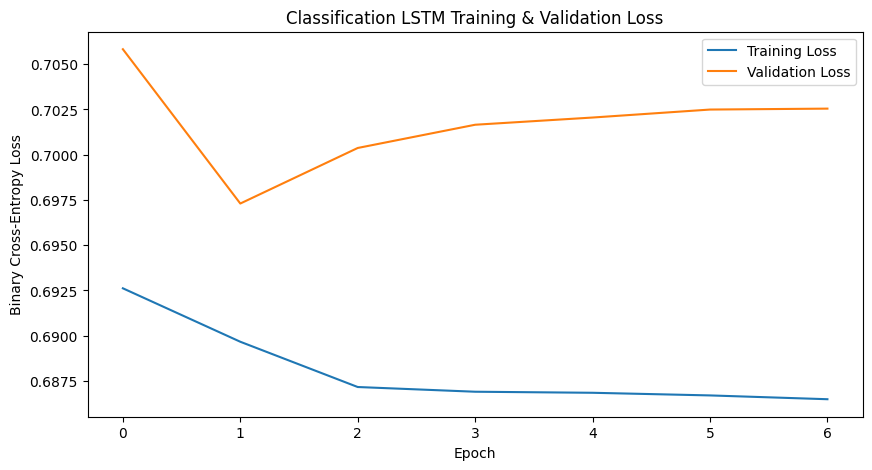

In [155]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_cls_losses,
    label="Training Loss"
)

plt.plot(
    val_cls_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Classification LSTM Training & Validation Loss")

plt.legend()
plt.show()

In [156]:
classifier.eval()

with torch.no_grad():

    test_logits = classifier(
        X_test_cls_tensor.to(device)
    )

    test_probabilities = torch.sigmoid(
        test_logits
    )

test_probabilities = (
    test_probabilities
    .cpu()
    .numpy()
    .flatten()
)

In [157]:
print(test_probabilities[:20])

[0.5453523  0.54550105 0.5446194  0.5442097  0.5438635  0.5436092
 0.54324734 0.5425953  0.5425155  0.5424739  0.5419183  0.54178274
 0.5417943  0.5422246  0.54281026 0.5432249  0.54356265 0.54384923
 0.5438425  0.54417545]


In [158]:
test_predictions_cls = (
    test_probabilities >= 0.5
).astype(int)

In [159]:
actual_directions = y_test_seq_cls.astype(int)

In [160]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [161]:
accuracy = accuracy_score(
    actual_directions,
    test_predictions_cls
)

precision = precision_score(
    actual_directions,
    test_predictions_cls,
    zero_division=0
)

recall = recall_score(
    actual_directions,
    test_predictions_cls,
    zero_division=0
)

f1 = f1_score(
    actual_directions,
    test_predictions_cls,
    zero_division=0
)

cm = confusion_matrix(
    actual_directions,
    test_predictions_cls
)

print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1 Score:  {f1:.2%}")

print("\nConfusion Matrix:")
print(cm)

Accuracy:  56.94%
Precision: 56.94%
Recall:    100.00%
F1 Score:  72.56%

Confusion Matrix:
[[  0 242]
 [  0 320]]


In [162]:
always_up_accuracy = np.mean(
    actual_directions == 1
)

print(
    f"LSTM Accuracy:      {accuracy:.2%}"
)

print(
    f"Always-Up Accuracy:  "
    f"{always_up_accuracy:.2%}"
)

LSTM Accuracy:      56.94%
Always-Up Accuracy:  56.94%


In [163]:
print(
    "Average predicted probability:",
    test_probabilities.mean()
)

print(
    "Minimum probability:",
    test_probabilities.min()
)

print(
    "Maximum probability:",
    test_probabilities.max()
)

print("\nPredicted classes:")

unique, counts = np.unique(
    test_predictions_cls,
    return_counts=True
)

print(dict(zip(unique, counts)))

Average predicted probability: 0.53981537
Minimum probability: 0.533313
Maximum probability: 0.5504559

Predicted classes:
{np.int64(1): np.int64(562)}


validation probabilities

In [164]:
classifier.eval()

with torch.no_grad():

    val_logits = classifier(
        X_val_cls_tensor.to(device)
    )

    val_probabilities = torch.sigmoid(
        val_logits
    )

val_probabilities = (
    val_probabilities
    .cpu()
    .numpy()
    .flatten()
)

In [165]:
val_actual_returns = y_val_seq

In [167]:
print(len(val_probabilities)==len(val_actual_returns))

True


signal function

In [171]:
def probabilities_to_signals(
    probabilities,
    long_threshold=0.55,
    short_threshold=0.45
):

    signals = np.zeros(
        len(probabilities)
    )

    signals[
        probabilities > long_threshold
    ] = 1

    signals[
        probabilities < short_threshold
    ] = -1

    return signals

backtest

In [172]:
def run_backtest(
    actual_returns,
    signals,
    initial_capital=10000,
    transaction_cost=0.0005
):

    backtest = pd.DataFrame({
        "Actual_Return": actual_returns,
        "Signal": signals
    })

    backtest["Strategy_Return"] = (
        backtest["Signal"] *
        backtest["Actual_Return"]
    )

    backtest["Trade"] = (
        backtest["Signal"]
        .diff()
        .abs()
        .fillna(backtest["Signal"].abs())
    )

    backtest["Strategy_Return_Net"] = (
        backtest["Strategy_Return"]
        - backtest["Trade"] * transaction_cost
    )

    backtest["Portfolio"] = (
        initial_capital *
        (
            1 +
            backtest["Strategy_Return_Net"]
        ).cumprod()
    )

    return backtest

In [173]:
thresholds = [
    (0.52, 0.48),
    (0.55, 0.45),
    (0.575, 0.425),
    (0.60, 0.40)
]

In [174]:
for long_threshold, short_threshold in thresholds:

    signals = probabilities_to_signals(
        val_probabilities,
        long_threshold,
        short_threshold
    )

    bt = run_backtest(
        val_actual_returns,
        signals
    )

    total_return = (
        bt["Portfolio"].iloc[-1] /
        10000 - 1
    )

    print(
        f"{long_threshold:.3f}/{short_threshold:.3f}"
        f" → Validation Return: "
        f"{total_return:.2%}"
    )

0.520/0.480 → Validation Return: 12.49%
0.550/0.450 → Validation Return: 8.57%
0.575/0.425 → Validation Return: 0.00%
0.600/0.400 → Validation Return: 0.00%


In [176]:
BEST_LONG_THRESHOLD = 0.52
BEST_SHORT_THRESHOLD = 0.48

In [189]:
classification_signals = probabilities_to_signals(
    test_probabilities,
    BEST_LONG_THRESHOLD,
    BEST_SHORT_THRESHOLD
)

In [178]:
unique, counts = np.unique(
    classification_signals,
    return_counts=True
)

print(dict(zip(unique, counts)))

{np.float64(1.0): np.int64(562)}


In [179]:
classification_backtest = run_backtest(
    actual_returns=y_test_seq,
    signals=classification_signals,
    initial_capital=10000,
    transaction_cost=0.0005
)

In [180]:
test_dates = test_df.index[
    seq_length - 1:
]

classification_backtest.index = test_dates

In [182]:
len(classification_backtest) == len(test_dates)

True

In [183]:
classification_backtest[
    "Buy_Hold"
] = (
    10000 *
    (
        1 +
        classification_backtest[
            "Actual_Return"
        ]
    ).cumprod()
)

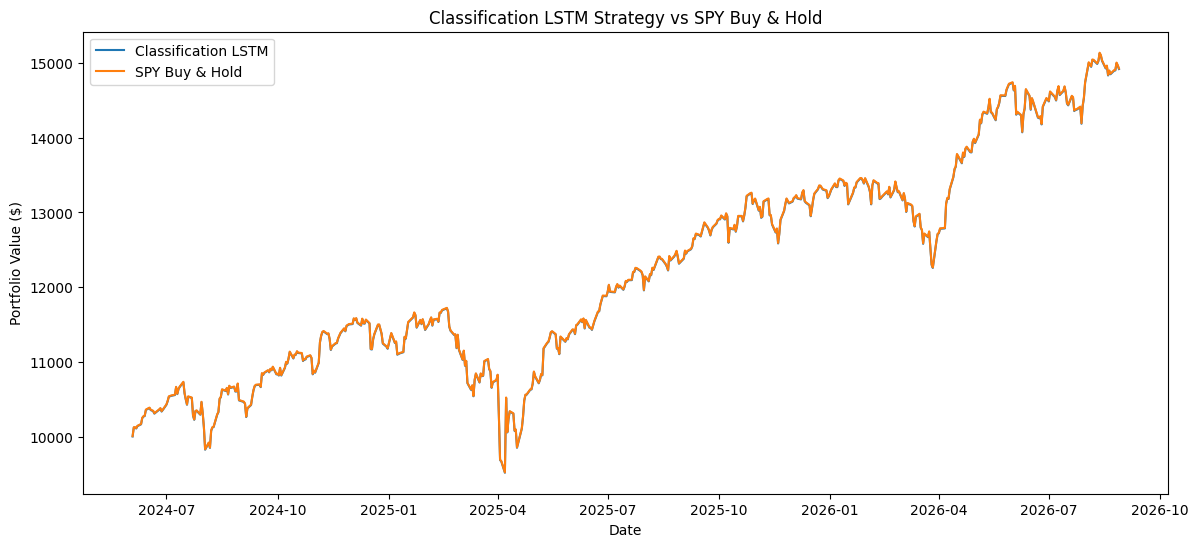

In [184]:
plt.figure(figsize=(14, 6))

plt.plot(
    classification_backtest.index,
    classification_backtest["Portfolio"],
    label="Classification LSTM"
)

plt.plot(
    classification_backtest.index,
    classification_backtest["Buy_Hold"],
    label="SPY Buy & Hold"
)

plt.title(
    "Classification LSTM Strategy vs SPY Buy & Hold"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")

plt.legend()
plt.show()

In [186]:
strategy_returns = (
    classification_backtest[
        "Strategy_Return_Net"
    ]
)

buy_hold_returns = (
    classification_backtest[
        "Actual_Return"
    ]
)

strategy_total_return = (
    classification_backtest[
        "Portfolio"
    ].iloc[-1] / 10000 - 1
)

buy_hold_total_return = (
    classification_backtest[
        "Buy_Hold"
    ].iloc[-1] / 10000 - 1
)

strategy_sharpe = (
    strategy_returns.mean() /
    strategy_returns.std()
) * np.sqrt(252)

buy_hold_sharpe = (
    buy_hold_returns.mean() /
    buy_hold_returns.std()
) * np.sqrt(252)

strategy_drawdown = max_drawdown(
    strategy_returns
)

buy_hold_drawdown = max_drawdown(
    buy_hold_returns
)

num_trades = (
    classification_backtest["Trade"] > 0
).sum()

In [187]:
print("----- CLASSIFICATION LSTM -----")

print(
    f"Total Return: "
    f"{strategy_total_return:.2%}"
)

print(
    f"Sharpe Ratio: "
    f"{strategy_sharpe:.2f}"
)

print(
    f"Max Drawdown: "
    f"{strategy_drawdown:.2%}"
)

print(
    f"Trades: {num_trades}"
)

print()

print("----- SPY BUY & HOLD -----")

print(
    f"Total Return: "
    f"{buy_hold_total_return:.2%}"
)

print(
    f"Sharpe Ratio: "
    f"{buy_hold_sharpe:.2f}"
)

print(
    f"Max Drawdown: "
    f"{buy_hold_drawdown:.2%}"
)

----- CLASSIFICATION LSTM -----
Total Return: 49.18%
Sharpe Ratio: 1.18
Max Drawdown: -18.76%
Trades: 1

----- SPY BUY & HOLD -----
Total Return: 49.25%
Sharpe Ratio: 1.18
Max Drawdown: -18.76%


In [190]:
print("Test probability statistics:")
print(f"Mean: {test_probabilities.mean():.4f}")
print(f"Min:  {test_probabilities.min():.4f}")
print(f"Max:  {test_probabilities.max():.4f}")

print("\nSignal counts:")
unique, counts = np.unique(
    classification_signals,
    return_counts=True
)

for signal, count in zip(unique, counts):
    print(
        f"Signal {int(signal):2d}: "
        f"{count} days "
        f"({count / len(classification_signals):.2%})"
    )

Test probability statistics:
Mean: 0.5398
Min:  0.5333
Max:  0.5505

Signal counts:
Signal  1: 562 days (100.00%)


logistic regression baseline

In [191]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train_direction
)

LogisticRegression(max_iter=1000, random_state=42)

In [192]:
logistic_test_probabilities = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

logistic_test_predictions = (
    logistic_test_probabilities >= 0.5
).astype(int)

In [193]:
logistic_accuracy = accuracy_score(
    y_test_direction,
    logistic_test_predictions
)

logistic_precision = precision_score(
    y_test_direction,
    logistic_test_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test_direction,
    logistic_test_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test_direction,
    logistic_test_predictions,
    zero_division=0
)

print(f"Accuracy:  {logistic_accuracy:.2%}")
print(f"Precision: {logistic_precision:.2%}")
print(f"Recall:    {logistic_recall:.2%}")
print(f"F1 Score:  {logistic_f1:.2%}")

Accuracy:  56.84%
Precision: 56.80%
Recall:    99.72%
F1 Score:  72.37%


In [194]:
print("\nProbability statistics:")
print(f"Mean: {logistic_test_probabilities.mean():.4f}")
print(f"Min:  {logistic_test_probabilities.min():.4f}")
print(f"Max:  {logistic_test_probabilities.max():.4f}")

print("\nPrediction counts:")

unique, counts = np.unique(
    logistic_test_predictions,
    return_counts=True
)

for prediction, count in zip(unique, counts):
    print(
        f"Prediction {prediction}: "
        f"{count} days "
        f"({count / len(logistic_test_predictions):.2%})"
    )


Probability statistics:
Mean: 0.5816
Min:  0.2160
Max:  0.7210

Prediction counts:
Prediction 0: 3 days (0.48%)
Prediction 1: 618 days (99.52%)


In [197]:
logistic_probs_aligned = logistic_test_probabilities[seq_length - 1:]
logistic_preds_aligned = logistic_test_predictions[seq_length - 1:]
y_direction_aligned = y_test_direction[seq_length - 1:]

len(logistic_preds_aligned) == len(test_predictions_cls)

True

In [198]:
len(logistic_preds_aligned) == len(y_test_seq)

True

In [199]:
lstm_cls_accuracy = accuracy_score(
    y_direction_aligned,
    test_predictions_cls
)

logistic_accuracy_aligned = accuracy_score(
    y_direction_aligned,
    logistic_preds_aligned
)

always_up_accuracy = np.mean(
    y_direction_aligned == 1
)

print(f"Classification LSTM: {lstm_cls_accuracy:.2%}")
print(f"Logistic Regression: {logistic_accuracy_aligned:.2%}")
print(f"Always-Up Baseline:  {always_up_accuracy:.2%}")

Classification LSTM: 56.94%
Logistic Regression: 57.12%
Always-Up Baseline:  56.94%


In [200]:
accuracy_comparison = pd.DataFrame({
    "Model": [
        "Classification LSTM",
        "Logistic Regression",
        "Always-Up"
    ],
    "Accuracy": [
        lstm_cls_accuracy,
        logistic_accuracy_aligned,
        always_up_accuracy
    ]
})

accuracy_comparison

,Model,Accuracy
0,Classification LSTM,0.569395
1,Logistic Regression,0.571174
2,Always-Up,0.569395


final backtest comparison

In [201]:
logistic_signals = probabilities_to_signals(
    logistic_probs_aligned,
    BEST_LONG_THRESHOLD,
    BEST_SHORT_THRESHOLD
)

In [202]:
logistic_backtest = run_backtest(
    actual_returns=y_test_seq,
    signals=logistic_signals,
    initial_capital=10000,
    transaction_cost=0.0005
)

logistic_backtest.index = test_dates

In [203]:
logistic_returns = logistic_backtest["Strategy_Return_Net"]

logistic_total_return = (
    logistic_backtest["Portfolio"].iloc[-1]
    / 10000 - 1
)

logistic_sharpe = (
    logistic_returns.mean()
    / logistic_returns.std()
) * np.sqrt(252)

logistic_drawdown = max_drawdown(
    logistic_returns
)

logistic_trades = (
    logistic_backtest["Trade"] > 0
).sum()

In [204]:
strategy_comparison = pd.DataFrame({
    "Strategy": [
        "Classification LSTM",
        "Logistic Regression",
        "SPY Buy & Hold"
    ],

    "Total Return": [
        strategy_total_return,
        logistic_total_return,
        buy_hold_total_return
    ],

    "Sharpe Ratio": [
        strategy_sharpe,
        logistic_sharpe,
        buy_hold_sharpe
    ],

    "Max Drawdown": [
        strategy_drawdown,
        logistic_drawdown,
        buy_hold_drawdown
    ],

    "Trades": [
        num_trades,
        logistic_trades,
        1
    ]
})

strategy_comparison

,Strategy,Total Return,Sharpe Ratio,Max Drawdown,Trades
0,Classification LSTM,0.491755,1.175686,-0.187552,1
1,Logistic Regression,0.355813,0.916282,-0.250474,11
2,SPY Buy & Hold,0.492501,1.177052,-0.187552,1


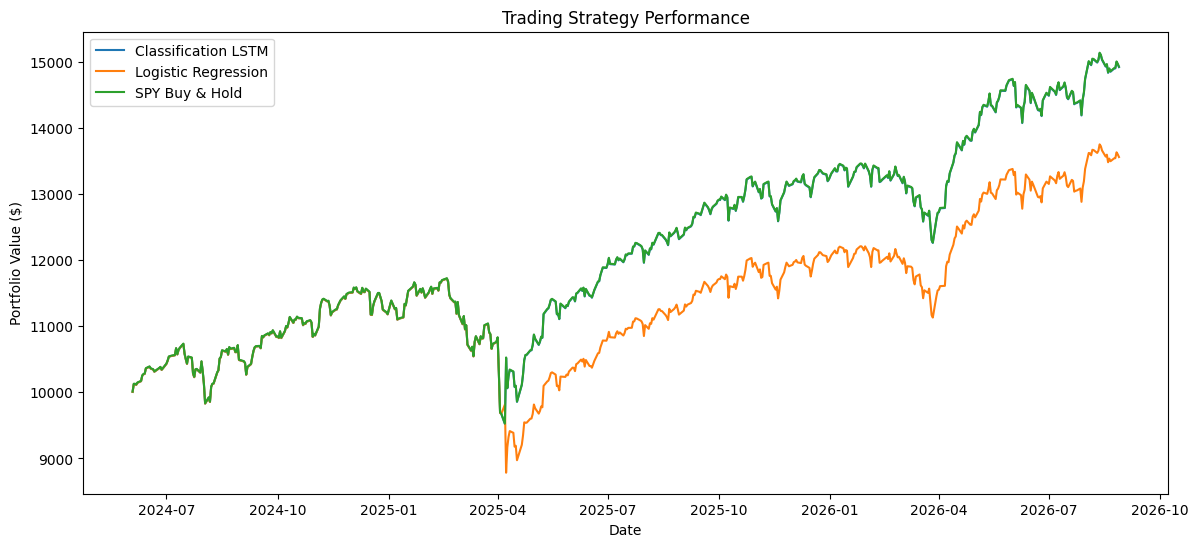

In [205]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    classification_backtest["Portfolio"],
    label="Classification LSTM"
)

plt.plot(
    test_dates,
    logistic_backtest["Portfolio"],
    label="Logistic Regression"
)

plt.plot(
    test_dates,
    classification_backtest["Buy_Hold"],
    label="SPY Buy & Hold"
)

plt.title("Trading Strategy Performance")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()

plt.show()

In [207]:
def drawdown_series(portfolio):

    running_max = portfolio.cummax()

    return (
        portfolio - running_max
    ) / running_max

In [208]:
lstm_dd = drawdown_series(
    classification_backtest["Portfolio"]
)

logistic_dd = drawdown_series(
    logistic_backtest["Portfolio"]
)

spy_dd = drawdown_series(
    classification_backtest["Buy_Hold"]
)

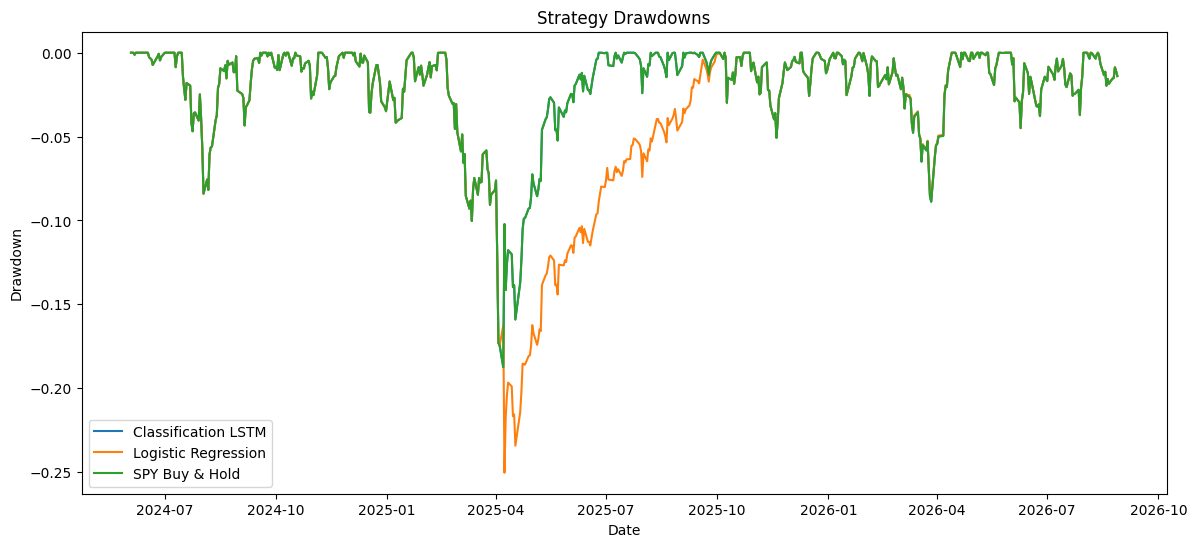

In [209]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    lstm_dd,
    label="Classification LSTM"
)

plt.plot(
    test_dates,
    logistic_dd,
    label="Logistic Regression"
)

plt.plot(
    test_dates,
    spy_dd,
    label="SPY Buy & Hold"
)

plt.title("Strategy Drawdowns")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()

plt.show()

In [210]:
torch.save(
    classifier.state_dict(),
    "lstm_classifier.pth"
)

In [211]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

joblib.dump(
    logistic_model,
    "logistic_model.pkl"
)

['logistic_model.pkl']

In [212]:
import json

config = {
    "ticker": "SPY",
    "sequence_length": seq_length,
    "features": features,
    "long_threshold": BEST_LONG_THRESHOLD,
    "short_threshold": BEST_SHORT_THRESHOLD,
    "transaction_cost": 0.0005,
    "initial_capital": 10000
}

with open("config.json", "w") as f:
    json.dump(
        config,
        f,
        indent=4
    )

In [214]:
ticker = "SPY"
yf.download(
    ticker,
    start="2010-01-01",
    end="2026-09-01",
    auto_adjust=True)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2010-01-04,84.368973,84.413638,83.014067,83.654298,118944600
2010-01-05,84.592323,84.629548,84.011650,84.316879,111579900
2010-01-06,84.651855,84.860302,84.443409,84.510407,116074400
2010-01-07,85.009209,85.113432,84.257309,84.495534,131091100
2010-01-08,85.292130,85.329355,84.614679,84.785900,126402800
...,...,...,...,...,...
2026-08-25,764.012756,764.880657,761.159855,764.262137,27422300
2026-08-26,764.182373,765.449186,762.037674,762.835681,28751600
